# 🔬 Sub-BPM Resolution Pure Template Benchmark
This notebook generates the structured bipolar pulse template for every 0.5 BPM interval from 60 to 180 BPM, utilizing continuous-phase float arrays. It uses the pre-loaded Librosa array to fix MP3 codec truncation issues.


In [ ]:
import librosa
import numpy as np
import time
from collections import deque
import warnings
warnings.filterwarnings('ignore')

# Import core infrastructure
import core.Listener as ListenerModule
from IPython.display import display, clear_output
import matplotlib.pyplot as plt

def default_infos():
    return {
        "startServer"     : False ,
        "useMicrophone"   : True  ,
        "HARDWARE_MODE"   : "simulation",
        "printTimeOfCalculation" : False ,
        "printModesDetails"      : True ,
        "printMicrophoneDetails" : False ,
        "printAppDetails"        : False ,
        "printAsservmentDetails" : False ,
        "printConfigurationLoads": False ,
        "printConfigChanges"     : False ,
        "modesToPrintDetails"    : ["PSG"]
    }

AUDIO_FILE = 'mp3_files/Nightcall.mp3'



### 1. Ground Truth Benchmark


In [2]:
print(f"Loading {AUDIO_FILE} full audio for Ground Truth Benchmarks...")
y_full, sr = librosa.load(AUDIO_FILE, sr=44100) # Force 44.1kHz to match our standard

print("Running non-causal Librosa Beat Track...")
onset_env_full = librosa.onset.onset_strength(y=y_full, sr=sr)
tempo_librosa, beat_frames_true = librosa.beat.beat_track(onset_envelope=onset_env_full, sr=sr)
true_beat_times = librosa.frames_to_time(beat_frames_true, sr=sr)
print(f"✅ Ground Truth Extraction Complete! Librosa Global BPM: {tempo_librosa[0] if isinstance(tempo_librosa, np.ndarray) else tempo_librosa:.1f}")



Loading mp3_files/Nightcall.mp3 full audio for Ground Truth Benchmarks...
Running non-causal Librosa Beat Track...
✅ Ground Truth Extraction Complete! Librosa Global BPM: 90.7


### 2. High Resolution Continuous-Phase Template Evaluation


In [5]:
class Robust_Simulated_Microphone:
    def __init__(self, y_full_array, bandValues, infos):
        self.bandValues = bandValues
        self.nb_of_fft_band = len(self.bandValues)
        
        self.sample_rate = 44100
        self.buffer_size = 1024 
        self.audio_data = np.zeros(self.buffer_size)
        
        # Use Librosa's array directly to avoid Torchaudio MP3 truncation
        self.full_audio = y_full_array
        self.total_samples = len(self.full_audio)
        self.current_pos = 0
        
        fft_size = self.buffer_size // 2 + 1
        self.weight_matrix = np.zeros((self.nb_of_fft_band, fft_size))
        
        def hz_to_mel(f): return 2595 * np.log10(1 + f / 700.0)
        def mel_to_hz(m): return 700 * (10**(m / 2595.0) - 1)
        
        lower_mel = hz_to_mel(20)
        upper_mel = hz_to_mel(20000)
        mel_points = np.linspace(lower_mel, upper_mel, self.nb_of_fft_band + 2)
        hz_points = mel_to_hz(mel_points)
        bin_points = np.floor((self.buffer_size + 1) * hz_points / self.sample_rate).astype(int)
        
        for i in range(self.nb_of_fft_band):
            start = min(bin_points[i], fft_size - 1)
            mid = min(bin_points[i + 1], fft_size - 1)
            end = min(bin_points[i + 2], fft_size - 1)
            if mid > start:
                self.weight_matrix[i, start:mid] = np.linspace(0, 1, mid - start, endpoint=False)
            if end > mid:
                self.weight_matrix[i, mid:end] = np.linspace(1, 0, end - mid, endpoint=False)
            band_sum = np.sum(self.weight_matrix[i, :])
            if band_sum > 0:
                self.weight_matrix[i, :] /= band_sum
                
        self.raw_fft_history = None
        self.high_res_flux = 0.0

    def pop_chunk(self, chunk_size=1024):
        if self.current_pos + chunk_size > self.total_samples:
            return False 
        
        incoming = self.full_audio[self.current_pos : self.current_pos + chunk_size]
        self.current_pos += chunk_size
        self.audio_data = np.roll(self.audio_data, -chunk_size)
        self.audio_data[-chunk_size:] = incoming
        return True

    def calculate_fft(self):
        windowed_data = self.audio_data * np.hanning(self.buffer_size)
        fft_result = np.abs(np.fft.rfft(windowed_data))
        
        scale = 150.0 / (self.buffer_size / 1024.0)
        mel_bands = np.dot(self.weight_matrix, fft_result) * scale
        for i in range(self.nb_of_fft_band):
            self.bandValues[i] = int(mel_bands[i])

        if self.raw_fft_history is not None:
            freq_diff = np.maximum(0, fft_result[5:300] - self.raw_fft_history[5:300])
            self.high_res_flux = np.sum(freq_diff)
        self.raw_fft_history = fft_result
        
        
def continuous_phase_sweep(odf_buffer):
    odf_size = len(odf_buffer)
    decay_curve = np.exp(-1.5 * np.linspace(1.0, 0.0, odf_size))
    weighted_buffer = odf_buffer * decay_curve
    
    best_overall_score = -float('inf')
    best_overall_bpm = 60.0
    
    buffer_indices = np.arange(odf_size)
    
    # Explicit 0.5 BPM sub-resolution array
    bpm_evals = np.arange(60.0, 180.5, 1)
    all_scores = []
    
    btrack_fps = 60.0
    
    for bpm_val in bpm_evals:
        # Calculate tau as a continuous float value
        tau_val = 60.0 * btrack_fps / bpm_val
        
        # We sweep integral phase offsets from 0 to ceil(tau_val)
        p_max = int(np.ceil(tau_val))
        p_scores = np.zeros(p_max)
        
        for p in range(p_max):
            # Calculate floating point phase for each buffer index
            phase_float = (buffer_indices - (odf_size - 1 - p)) % tau_val
            norm_phi = phase_float / tau_val # Normalized phase 0.0 -> 1.0
            
            # Construct bipolar vector array map
            template_vals = np.full(odf_size, -0.2)
            template_vals[(norm_phi <= 0.05) | (norm_phi >= 0.95)] = 1.0
            template_vals[(norm_phi >= 0.45) & (norm_phi <= 0.55)] = 0.6
            template_vals[(norm_phi >= 0.22) & (norm_phi <= 0.28)] = 0.3
            template_vals[(norm_phi >= 0.72) & (norm_phi <= 0.78)] = 0.3
            
            p_scores[p] = np.sum(weighted_buffer * template_vals)
            
        tau_max_score = np.max(p_scores)
        
        # Gaussian smoothing to prioritize plausible 120bpm range
        gaussian_weight = np.exp(-0.5 * ((bpm_val - 120.0) / 20.0)**2)
        weighted_score = tau_max_score * (0.8 + 0.2 * gaussian_weight)
        
        all_scores.append(weighted_score)
        
        if weighted_score > best_overall_score:
            best_overall_score = weighted_score
            best_overall_bpm = bpm_val
            
    return best_overall_bpm, all_scores, bpm_evals



### 3. Execution Engine


In [6]:
infos = default_infos()
infos["printAsservmentDetails"] = False 
infos["useMicrophone"] = True

SIMULATED_FPS = 60.0
TIME_PER_FRAME = 1.0 / SIMULATED_FPS
CHUNK_SIZE_FOR_60FPS = int(44100 / SIMULATED_FPS)

class MockTime:
    def __init__(self):
        self.current_time = 0.0
    def time(self):
        return self.current_time

mock_timer = MockTime()
ListenerModule.time.time = mock_timer.time

listener = ListenerModule.Listener(infos)
mic = Robust_Simulated_Microphone(y_full, listener.fft_band_values, infos)
listener.hasBeenSilenceCalibrated = True
listener.hasBeenBBCalibrated = True
listener.calibrate_silence = lambda: None
listener.calibrate_bb = lambda: None

history_time = []
history_bpm = []
history_all_scores = []
audio_time = 0.0

frames_since_sweep = 0
frames_between_sweep = int(0.2 * SIMULATED_FPS) 

print("🚀 Starting High-Res Brute-Force Sweep Simulation...")

while mic.pop_chunk(CHUNK_SIZE_FOR_60FPS):
    mic.calculate_fft()
    listener.update() 
    
    if frames_since_sweep >= frames_between_sweep:
        best_bpm, all_scores, bpm_eval_range = continuous_phase_sweep(listener.odf_buffer)
        
        history_time.append(audio_time)
        history_bpm.append(best_bpm)
        history_all_scores.append(all_scores)
        frames_since_sweep = 0
        
        if len(history_bpm) % 25 == 0:
            print(f"Time: {audio_time:.2f}s | Optimal Match: {best_bpm:.1f} BPM")
            
    frames_since_sweep += 1
    audio_time += TIME_PER_FRAME
    mock_timer.current_time = audio_time

print("Simulated complete!")



🚀 Starting High-Res Brute-Force Sweep Simulation...
Time: 5.00s | Optimal Match: 119.0 BPM
Time: 10.00s | Optimal Match: 117.0 BPM
Time: 15.00s | Optimal Match: 92.0 BPM
Time: 20.00s | Optimal Match: 91.0 BPM
Time: 25.00s | Optimal Match: 91.0 BPM
Time: 30.00s | Optimal Match: 91.0 BPM
Time: 35.00s | Optimal Match: 91.0 BPM
Time: 40.00s | Optimal Match: 91.0 BPM
Time: 45.00s | Optimal Match: 91.0 BPM
Time: 50.00s | Optimal Match: 91.0 BPM
Time: 55.00s | Optimal Match: 91.0 BPM
Time: 60.00s | Optimal Match: 90.0 BPM
Time: 65.00s | Optimal Match: 91.0 BPM
Time: 70.00s | Optimal Match: 90.0 BPM
Time: 75.00s | Optimal Match: 91.0 BPM
Time: 80.00s | Optimal Match: 91.0 BPM
Time: 85.00s | Optimal Match: 91.0 BPM
Time: 90.00s | Optimal Match: 91.0 BPM
Time: 95.00s | Optimal Match: 91.0 BPM
Time: 100.00s | Optimal Match: 90.0 BPM
Time: 105.00s | Optimal Match: 91.0 BPM
Time: 110.00s | Optimal Match: 91.0 BPM
Time: 115.00s | Optimal Match: 91.0 BPM
Time: 120.00s | Optimal Match: 91.0 BPM
Time: 

KeyboardInterrupt: 

### 4. Plot Evaluation


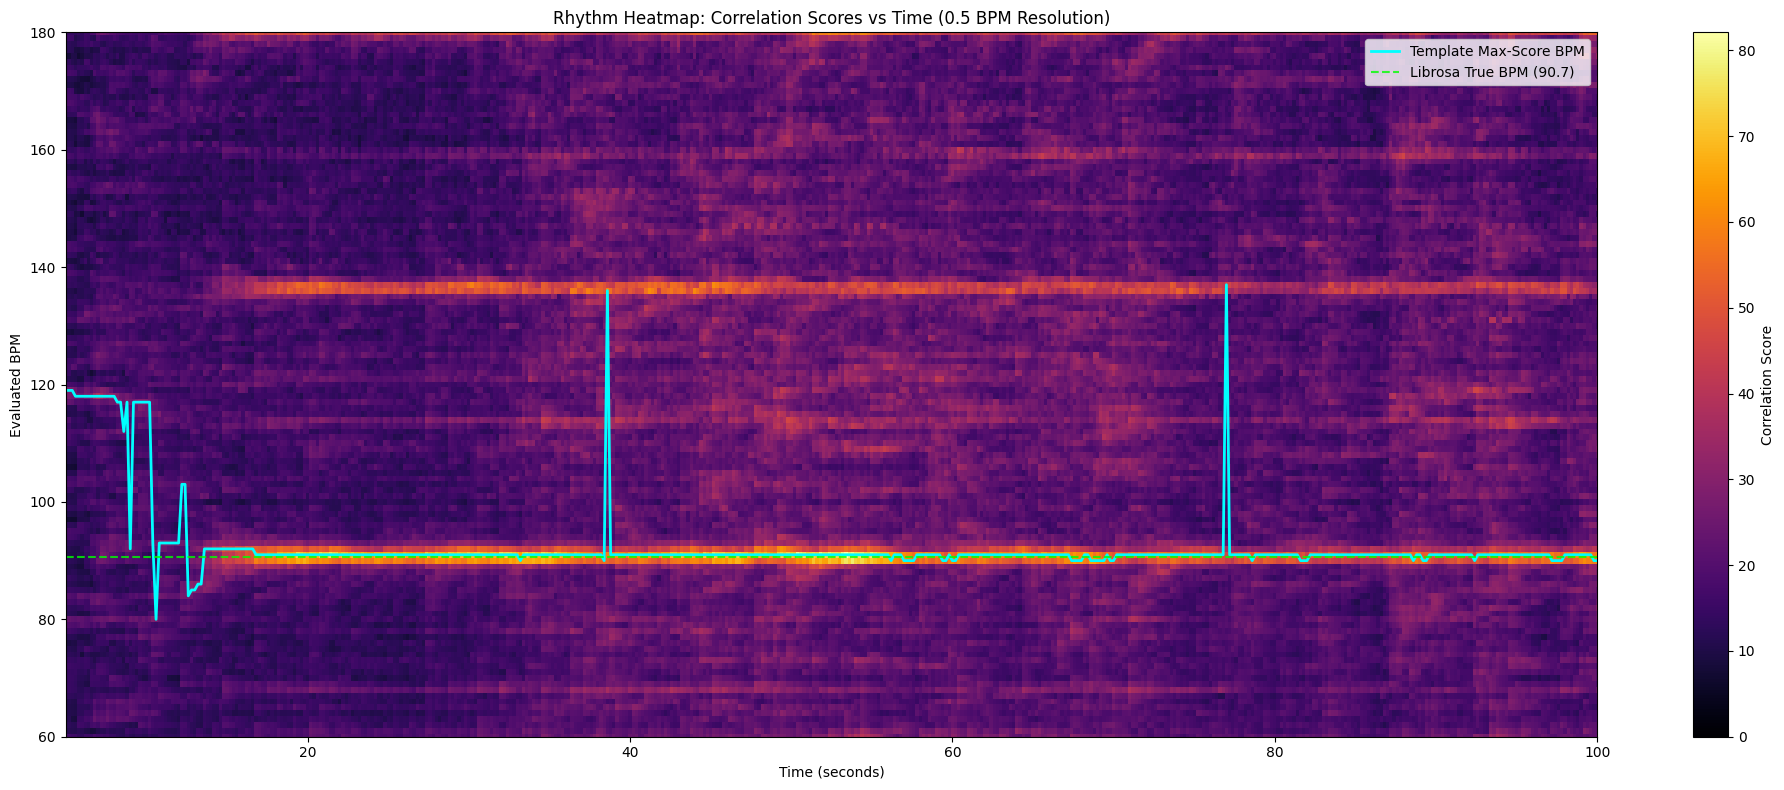

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 8))

# Convert scores to 2D numpy array [Time, BPM] -> [BPM, Time]
score_matrix = np.array(history_all_scores).T

time_grid = np.array(history_time)
bpm_grid = np.array(bpm_eval_range)

plt.pcolormesh(time_grid, bpm_grid, score_matrix, shading='auto', cmap='inferno')
plt.colorbar(label='Correlation Score')

plt.plot(history_time, history_bpm, label='Template Max-Score BPM', color='cyan', linewidth=2)

true_tempo = float(tempo_librosa[0] if isinstance(tempo_librosa, np.ndarray) else tempo_librosa)
plt.axhline(y=true_tempo, color='lime', linestyle='--', alpha=0.8, label=f'Librosa True BPM ({true_tempo:.1f})')

plt.title('Rhythm Heatmap: Correlation Scores vs Time (0.5 BPM Resolution)')
plt.xlabel('Time (seconds)')
plt.ylabel('Evaluated BPM')
plt.xlim(5.0, min(100.0, time_grid[-1] if len(time_grid) > 0 else 25.0)) # Show up to the first 100 seconds
plt.ylim(min(bpm_grid), max(bpm_grid))
plt.legend()
plt.tight_layout()
plt.show()

